# 7.5 Cross-Source — General Insights

**Input:** All sources + Bluesky + Reddit  
**Output:** Attention overview, aggregated attention, social buzz, polymarket composites

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. General Insights — 5-Panel Attention Overview](#1-general-insights--5-panel-attention-overview)
- [2. Polymarket + Aggregated Attention](#2-polymarket--aggregated-attention)
- [3. Social Buzz Volume — Biden→Harris Transition](#3-social-buzz-volume--bidenharris-transition)
- [4. Polymarket × Multi-Source Composite](#4-polymarket--multi-source-composite)
- [5. Simplified Composite (No Labels)](#5-simplified-composite-no-labels)
- [6. Odds + Buzz with Flashpoints](#6-odds--buzz-with-flashpoints)


## Setup

In [2]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

import house_style as _hs
importlib.reload(_hs)  # force reload — voorkomt stale __pycache__ versie

from house_style import (
    apply_style,
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    PALETTE,
    EVENTS,
    add_events, event_legend_handles,
    C_VIX, C_SP500,
    C_FEAR, C_ANGER, C_TRUST, C_DISGUST, C_SADNESS, C_JOY, C_ANTICIPATION,
    BLUESKY_BLUE, REDDIT_ORG,
)
apply_style()



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BRONZE = Path('../../Data/1_Bronze')
SILVER = Path('../../Data/2_Silver')

# ── Colour aliases ─────────────────────────────────────────────────────────
C_TRUMP  = REPUBLICAN
C_HARRIS = DEMOCRAT
C_DEM    = DEMOCRAT
C_REP    = REPUBLICAN
C_CEN    = NEUTRAL
C_MARKET = '#2ec4b6'
C_POLL   = '#9b5de5'

EVENT_DATES = [pd.Timestamp(date) for _, date, _ in EVENTS]

In [3]:
# ── Newspaper features ────────────────────────────────────────────────────────────
nlp  = pd.read_csv(SILVER / 'Newspapers/nlp_features_newspapers.csv',  parse_dates=['date'])
sent = pd.read_csv(SILVER / 'Newspapers/sentiment_features_newspapers.csv', parse_dates=['date'])

news = nlp.merge(sent, on='date', how='outer').sort_values('date').reset_index(drop=True)

# ── MediaCloud article-level → daily coverage metrics ────────────────────────
mc_raw = pd.read_csv(SILVER / 'Newspapers/mediacloud_articles_clean.csv', parse_dates=['date'])
mc_raw['mentions_trump']  = mc_raw['title_clean'].str.contains(r'\btrump\b',  case=False, na=False)
mc_raw['mentions_harris'] = mc_raw['title_clean'].str.contains(r'\bharris\b', case=False, na=False)

mc = (mc_raw.groupby('date')
     .agg(
         total_coverage   = ('title_clean', 'count'),
         n_trump_total    = ('mentions_trump',  'sum'),
         n_harris_total   = ('mentions_harris', 'sum'),
     )
     .reset_index())

denom = (mc['n_trump_total'] + mc['n_harris_total']).replace(0, float('nan'))
mc['trump_share']      = mc['n_trump_total'] / denom
mc['total_coverage_7d'] = mc['total_coverage'].rolling(7, min_periods=3).mean()
mc['trump_share_7d']    = mc['trump_share'].rolling(7,    min_periods=3).mean()

news = news.merge(mc, on='date', how='left')
print(f'Newspaper features : {news.shape}  ({news["date"].min().date()} → {news["date"].max().date()})')

Newspaper features : (123, 94)  (2024-07-05 → 2024-11-04)


In [4]:
# ── Polymarket odds ───────────────────────────────────────────────────────────────
poly = pd.read_csv(BRONZE / 'polymarket/polymarket_win_probabilities.csv',
                    parse_dates=['date'])
poly.columns = ['date', 'trump_odds', 'harris_odds']
poly = poly.sort_values('date').reset_index(drop=True)
print(f'Polymarket         : {poly.shape}  ({poly["date"].min().date()} → {poly["date"].max().date()})')
poly.head(3)

Polymarket         : (124, 3)  (2024-07-05 → 2024-11-05)


,date,trump_odds,harris_odds
0,2024-07-05,60.5,15.95
1,2024-07-06,62.5,13.85
2,2024-07-07,62.5,13.05


In [5]:
# ── Wikipedia polls → 7-day rolling average margin ─────────────────────────
polls_raw = pd.read_csv(BRONZE / 'polls/wikipedia_polls.csv')

# Parse numeric Trump/Harris support
for col in ['Trump', 'Harris']:
    polls_raw[col] = (
        polls_raw[col]
        .astype(str)
        .str.extract(r'([\d.]+)')[0]
        .astype(float)
    )

polls_raw['Date'] = pd.to_datetime(polls_raw['Date'], errors='coerce')
polls_raw = polls_raw.dropna(subset=['Date', 'Trump', 'Harris'])
polls_raw['margin'] = polls_raw['Trump'] - polls_raw['Harris']   # positive = Trump leads

# Daily average (multiple polls on same day)
daily_polls = (
    polls_raw.groupby('Date')[['Trump', 'Harris', 'margin']]
    .mean()
    .reset_index()
    .rename(columns={'Date': 'date', 'Trump': 'poll_trump', 'Harris': 'poll_harris'})
)

# Interpolate to full daily index, then smooth with 7-day rolling mean
date_idx = pd.date_range(daily_polls['date'].min(), daily_polls['date'].max(), freq='D')
daily_polls = (
    daily_polls.set_index('date')
    .reindex(date_idx)
    .interpolate('linear')
    .reset_index()
    .rename(columns={'index': 'date'})
)
daily_polls['poll_trump_7d']   = daily_polls['poll_trump'].rolling(7,  min_periods=1).mean()
daily_polls['poll_harris_7d']  = daily_polls['poll_harris'].rolling(7, min_periods=1).mean()
daily_polls['poll_margin_7d']  = daily_polls['margin'].rolling(7,      min_periods=1).mean()

print(f'Polls (daily interp): {daily_polls.shape}  ({daily_polls["date"].min().date()} → {daily_polls["date"].max().date()})')

Polls (daily interp): (134, 7)  (2024-06-24 → 2024-11-04)


In [6]:
# ── Financial market data ──────────────────────────────────────────────────────────
fin = pd.read_csv(BRONZE / 'financials/market.csv', parse_dates=['Date'])
fin = fin.rename(columns={'Date': 'date'})
fin = fin.sort_values('date').reset_index(drop=True)
print(f'Financials         : {fin.shape}  ({fin["date"].min().date()} → {fin["date"].max().date()})')

Financials         : (85, 6)  (2024-07-05 → 2024-11-01)


In [7]:
# ── Google Trends ──────────────────────────────────
gt = pd.read_csv(BRONZE / 'google trends/trends_daily_stitched.csv', parse_dates=['date'])
gt = gt.sort_values('date').reset_index(drop=True)

gt = gt.rename(columns={
    'trump':         'gt_trump',
    'kamala':        'gt_kamala',
    'biden':         'gt_biden',
    'elon musk':     'gt_elon',
    'election 2024': 'gt_election',
    'vote':          'gt_vote',
    'conspiracy':    'gt_conspiracy',
    'walz':          'gt_walz',
    'vance':         'gt_vance',
    'campaign':      'gt_campaign',
})

gt['gt_trump_share']       = gt['gt_trump'] / (gt['gt_trump'] + gt['gt_kamala']).replace(0, np.nan)
gt['gt_election_interest'] = gt['gt_election']

print(f'Google Trends      : {gt.shape}  ({gt["date"].min().date()} → {gt["date"].max().date()})')
gt.head(3)


Google Trends      : (123, 8)  (2024-07-05 → 2024-11-04)


,date,gt_trump,gt_kamala,gt_vance,gt_walz,gt_election,gt_trump_share,gt_election_interest
0,2024-07-05,3.0,1.0,0.0,0.0,0.0,0.75,0.0
1,2024-07-06,3.0,0.0,0.0,0.0,0.0,1.00,0.0
2,2024-07-07,2.0,0.0,0.0,0.0,0.0,1.00,0.0


In [8]:
# ── Bluesky — daily post counts ────────────────────────────────────────
bsky_raw = pd.read_csv(SILVER / 'Bluesky/bluesky_clean.csv')
bsky_raw['date'] = pd.to_datetime(bsky_raw['timestamp'], format='mixed', utc=True).dt.tz_convert(None).dt.normalize()
bsky_raw = bsky_raw[bsky_raw['date'] <= '2024-11-04']
bsky_daily = (bsky_raw.groupby(['date', 'candidate']).size()
              .unstack(fill_value=0).rename_axis(None, axis=1))
for col in ['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz']:
    if col not in bsky_daily.columns:
        bsky_daily[col] = 0
bsky_daily    = bsky_daily[['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz']]
bsky_daily_df = bsky_daily.copy()
bsky_total    = bsky_daily.sum(axis=1)
print(f'Bluesky: {bsky_daily.shape}  ({bsky_daily.index.min().date()} → {bsky_daily.index.max().date()})')


Bluesky: (123, 3)  (2024-07-05 → 2024-11-04)


In [9]:
# ── Reddit — daily post counts ──────────────────────────────────────────
reddit_raw = pd.read_parquet(SILVER / 'Reddit/reddit_posts_clean.parquet')
reddit_raw['date'] = pd.to_datetime(reddit_raw['created_utc'], utc=True).dt.tz_convert(None).dt.normalize()
reddit_daily = (reddit_raw.groupby(['date', 'candidate']).size()
                .unstack(fill_value=0).rename_axis(None, axis=1))
for col in ['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz']:
    if col not in reddit_daily.columns:
        reddit_daily[col] = 0
reddit_daily    = reddit_daily[['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz']]
reddit_daily_df = reddit_daily.copy()
reddit_total    = reddit_daily.sum(axis=1)
print(f'Reddit : {reddit_daily.shape}  ({reddit_daily.index.min().date()} → {reddit_daily.index.max().date()})')


Reddit : (122, 3)  (2024-07-05 → 2024-11-03)


In [10]:
# ── Merge all sources on full daily calendar ───────────────────────
# Build a full calendar from the earliest to latest date across ALL sources
_all_dates = pd.concat([
    news["date"], poly["date"], fin["date"], gt["date"]
], ignore_index=True).dropna()
_cal = pd.DataFrame({"date": pd.date_range(_all_dates.min(), _all_dates.max(), freq="D")})

df = (
    _cal
    .merge(news, on="date", how="left")
    .merge(poly, on="date", how="left")
    .merge(fin,  on="date", how="left")
    .merge(gt,   on="date", how="left")
)
df = df.sort_values("date").reset_index(drop=True)

# Diagnostics — check that each source is correctly joined
print(f'Master frame : {df.shape}')
print(f'Date range   : {df["date"].min().date()} → {df["date"].max().date()}')
print()
print("── Coverage per source (non-NaN days) ──────────────────────────────────")
checks = {
    "Polymarket (trump_odds)":   "trump_odds",
    "Financials (SP500)":        "SP500",
    "Google Trends (gt_trump)":  "gt_trump",
    "News coverage (total_cov)": "total_coverage",
    "News sentiment (vc_dem)":   next((c for c in ["vader_compound_mean_dem","news_sent_level"] if c in df.columns), None),
}
for label, col in checks.items():
    if col and col in df.columns:
        n = df[col].notna().sum()
        print(f"  {label:<35}: {n:3d} / {len(df)} days  "
              f"({df.loc[df[col].notna(), 'date'].min().date()} → {df.loc[df[col].notna(), 'date'].max().date()})")
    else:
        print(f"  {label:<35}: column not found")

print()
print("── Gaps in continuous sources ────────────────────────────────────")
for col, src in [("trump_odds", "Polymarket"), ("gt_trump", "Google Trends")]:
    if col in df.columns:
        gaps = df[col].isna().sum()
        if gaps:
            print(f"  {src}: {gaps} missing days (weekends or scraping gap)")
        else:
            print(f"  {src}: complete — no gaps")
print()
print("  S&P 500 / VIX: NaN on weekends and public holidays is NORMAL (markets closed)")

Master frame : (124, 108)
Date range   : 2024-07-05 → 2024-11-05

── Coverage per source (non-NaN days) ──────────────────────────────────
  Polymarket (trump_odds)            : 124 / 124 days  (2024-07-05 → 2024-11-05)
  Financials (SP500)                 :  85 / 124 days  (2024-07-05 → 2024-11-01)
  Google Trends (gt_trump)           : 123 / 124 days  (2024-07-05 → 2024-11-04)
  News coverage (total_cov)          : 123 / 124 days  (2024-07-05 → 2024-11-04)
  News sentiment (vc_dem)            : 123 / 124 days  (2024-07-05 → 2024-11-04)

── Gaps in continuous sources ────────────────────────────────────
  Polymarket: complete — no gaps
  Google Trends: 1 missing days (weekends or scraping gap)

  S&P 500 / VIX: NaN on weekends and public holidays is NORMAL (markets closed)


In [11]:
# ── Filter to campaign window: July 5 – November 4 ───────────────────────
df = df[(df['date'] >= '2024-07-05') & (df['date'] <= '2024-11-04')].reset_index(drop=True)
print(f'Filtered frame: {df.shape}  ({df["date"].min().date()} → {df["date"].max().date()})')


Filtered frame: (123, 108)  (2024-07-05 → 2024-11-04)


In [12]:
import matplotlib.lines as mlines

# ── Event helpers ──────────────────────────────────────────────────────────────
# EVENTS format: [(label, date_str, color), ...] imported from house_style
def add_events(ax, events=None, alpha=0.7):
    """Draw a coloured dashed vertical line for each event. No text on the plot."""
    if events is None:
        events = EVENTS
    for lbl, date_str, color in events:
        ax.axvline(pd.Timestamp(date_str), color=color,
                   linestyle='--', linewidth=1.3, alpha=alpha, zorder=3)

def event_legend(fig, ncol=3):
    """Place a coloured event legend centred at the bottom of fig."""
    handles = [
        mlines.Line2D([], [], color=c, linestyle='--', linewidth=2.5, label=lbl)
        for lbl, _, c in EVENTS
    ]
    fig.legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=ncol,
        facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
        fontsize=9, framealpha=0.95, borderpad=0.8,
    )

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')

def style_twin(ax2, ylabel=None, ylabel_color=TEXT_MUTED):
    """Apply dark-theme styling to a twinx axis."""
    ax2.set_facecolor(BG_PANEL)
    for sp in ax2.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
    ax2.tick_params(colors=TEXT_MUTED, labelsize=9)
    if ylabel:
        ax2.set_ylabel(ylabel, color=ylabel_color, fontsize=10)
    ax2.yaxis.label.set_color(ylabel_color)

# ── Helpers for general insights cells ──────────────────────────────────
def as_aligned(values, date_index):
    if values is None: return pd.Series(np.nan, index=date_index)
    if isinstance(values, pd.DataFrame): values = values.sum(axis=1)
    s = pd.Series(values)
    if isinstance(s.index, pd.DatetimeIndex):
        idx = pd.to_datetime(s.index, errors='coerce')
        if getattr(idx, 'tz', None) is not None: idx = idx.tz_convert(None)
        s = pd.Series(s.to_numpy(), index=idx.normalize()).groupby(level=0).mean().reindex(date_index)
    else:
        s = pd.Series(s.to_numpy())
        s.index = date_index if len(s) == len(date_index) else s.index
        s = s.reindex(date_index)
    return s.astype(float)

def zroll(series, window=7):
    s = pd.Series(series).rolling(window, min_periods=3).mean()
    mu, sd = s.mean(skipna=True), s.std(skipna=True)
    if pd.isna(sd) or sd == 0: return s * 0
    return (s - mu) / sd

def style_ax(ax, title):
    """Shared axis styling used across general-insights plots."""
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED, labelsize=9)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=0.6, alpha=0.5)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=12, fontweight='bold', loc='left', pad=10)

def style_ax_noevents(ax, title):
    """Variant used where event markers are optional/disabled."""
    style_ax(ax, title)


## 2. Polymarket + Aggregated Attention

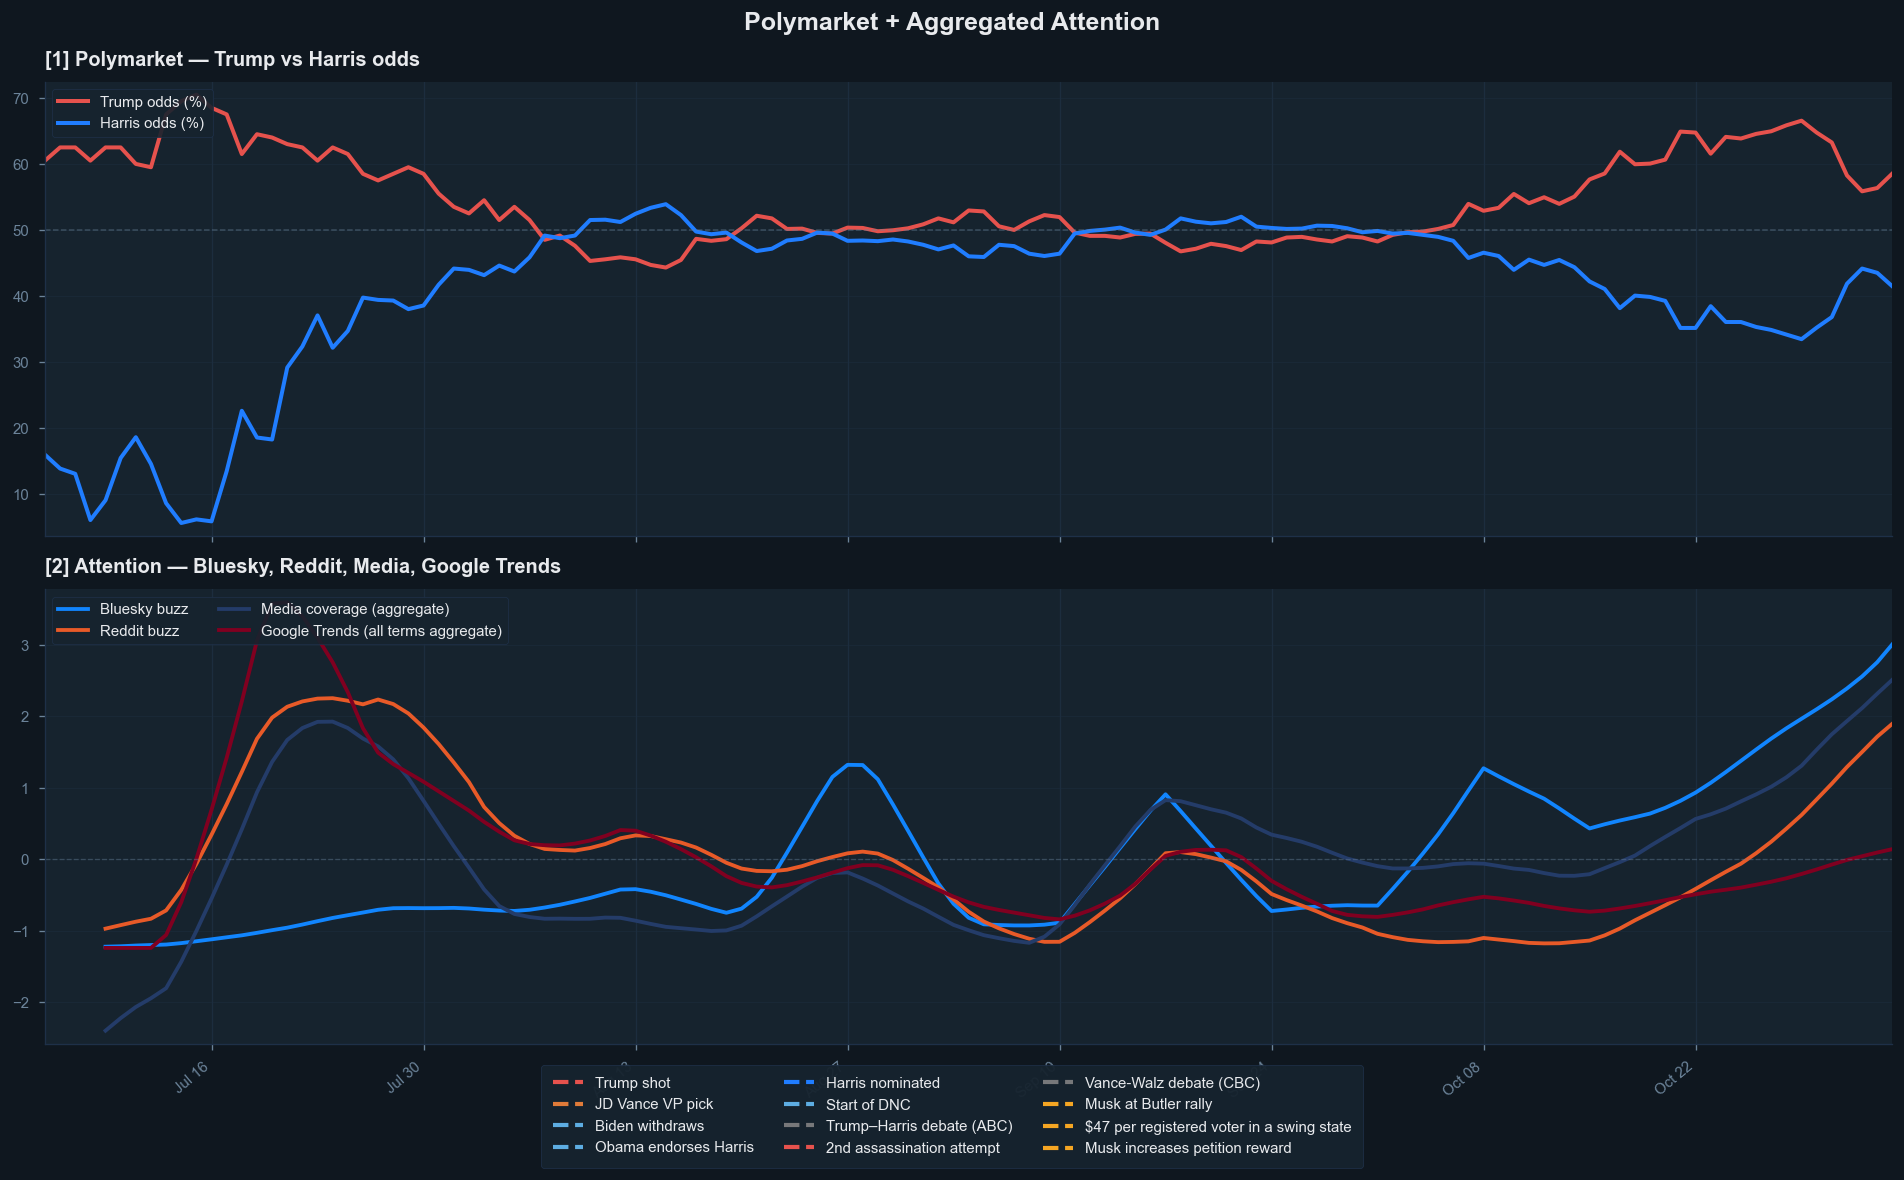

In [13]:
date_index = pd.to_datetime(df['date']).dt.normalize()

def nz(series):
    if series is None:
        return None
    return as_aligned(zroll(series), date_index)

# ── Aggregates ──────────────────────────────────────────────────────────────
gt_core_cols = [
    'gt_trump', 'gt_kamala', 'gt_biden', 'gt_elon',
    'gt_election', 'gt_vote', 'gt_conspiracy',
    'gt_walz', 'gt_vance', 'gt_campaign'
]
gt_core_cols = [c for c in gt_core_cols if c in df.columns]

gt_all_agg = df[gt_core_cols].sum(axis=1).rolling(7, min_periods=3).mean() if gt_core_cols else None
media_agg = df['total_coverage_7d'] if 'total_coverage_7d' in df.columns else None

bsky_series = as_aligned(bsky_total, date_index) if 'bsky_daily' in globals() and bsky_daily is not None else (
    as_aligned(df['bsky_posts'], date_index) if 'bsky_posts' in df.columns else None
)
reddit_series = as_aligned(reddit_total, date_index) if 'reddit_daily' in globals() and reddit_daily is not None else (
    as_aligned(df['reddit_posts'], date_index) if 'reddit_posts' in df.columns else None
)

bsky_agg = bsky_series.rolling(7, min_periods=3).mean() if bsky_series is not None else None
reddit_agg = reddit_series.rolling(7, min_periods=3).mean() if reddit_series is not None else None

# ── Plot: grouped charts (2 panels) ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle("Polymarket + Aggregated Attention", color=TEXT_PRIMARY, fontsize=15, fontweight='bold')

# 1) Polymarket
ax = axes[0]
style_ax(ax, "[1] Polymarket — Trump vs Harris odds")
if 'trump_odds' in df.columns:
    ax.plot(date_index, as_aligned(df['trump_odds'], date_index).values, color=C_TRUMP, lw=2.4, label='Trump odds (%)')
if 'harris_odds' in df.columns:
    ax.plot(date_index, as_aligned(df['harris_odds'], date_index).values, color=C_HARRIS, lw=2.4, label='Harris odds (%)')
ax.axhline(50, color=TEXT_MUTED, lw=0.9, ls='--', alpha=0.45)
ax.legend(loc='upper left')

# 2) Attention (genormaliseerd) — Bluesky en Reddit apart
ax = axes[1]
style_ax(ax, "[2] Attention — Bluesky, Reddit, Media, Google Trends")
series_to_plot = [
    ("Bluesky buzz", nz(bsky_agg), BLUESKY_BLUE),
    ("Reddit buzz", nz(reddit_agg), REDDIT_ORG),
    ("Media coverage (aggregate)", nz(media_agg), ACCENT),
    ("Google Trends (all terms aggregate)", nz(gt_all_agg), "#800020"),  # bordeaux
]
for label, y, color in series_to_plot:
    if y is not None and y.notna().any():
        ax.plot(date_index, y.values, lw=2.3, color=color, label=label)

ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.4)
ax.legend(loc='upper left', ncol=2)

for a in axes:
    fmt_xaxis(a)
    a.set_xlim(pd.Timestamp("2024-07-05"), pd.Timestamp("2024-11-04"))

plt.tight_layout()
fig.subplots_adjust(bottom=0.12)
event_legend(fig)
plt.show()



## 3. Social Buzz Volume — Biden→Harris Transition

NameError: name 'BUZZ_COLORS' is not defined

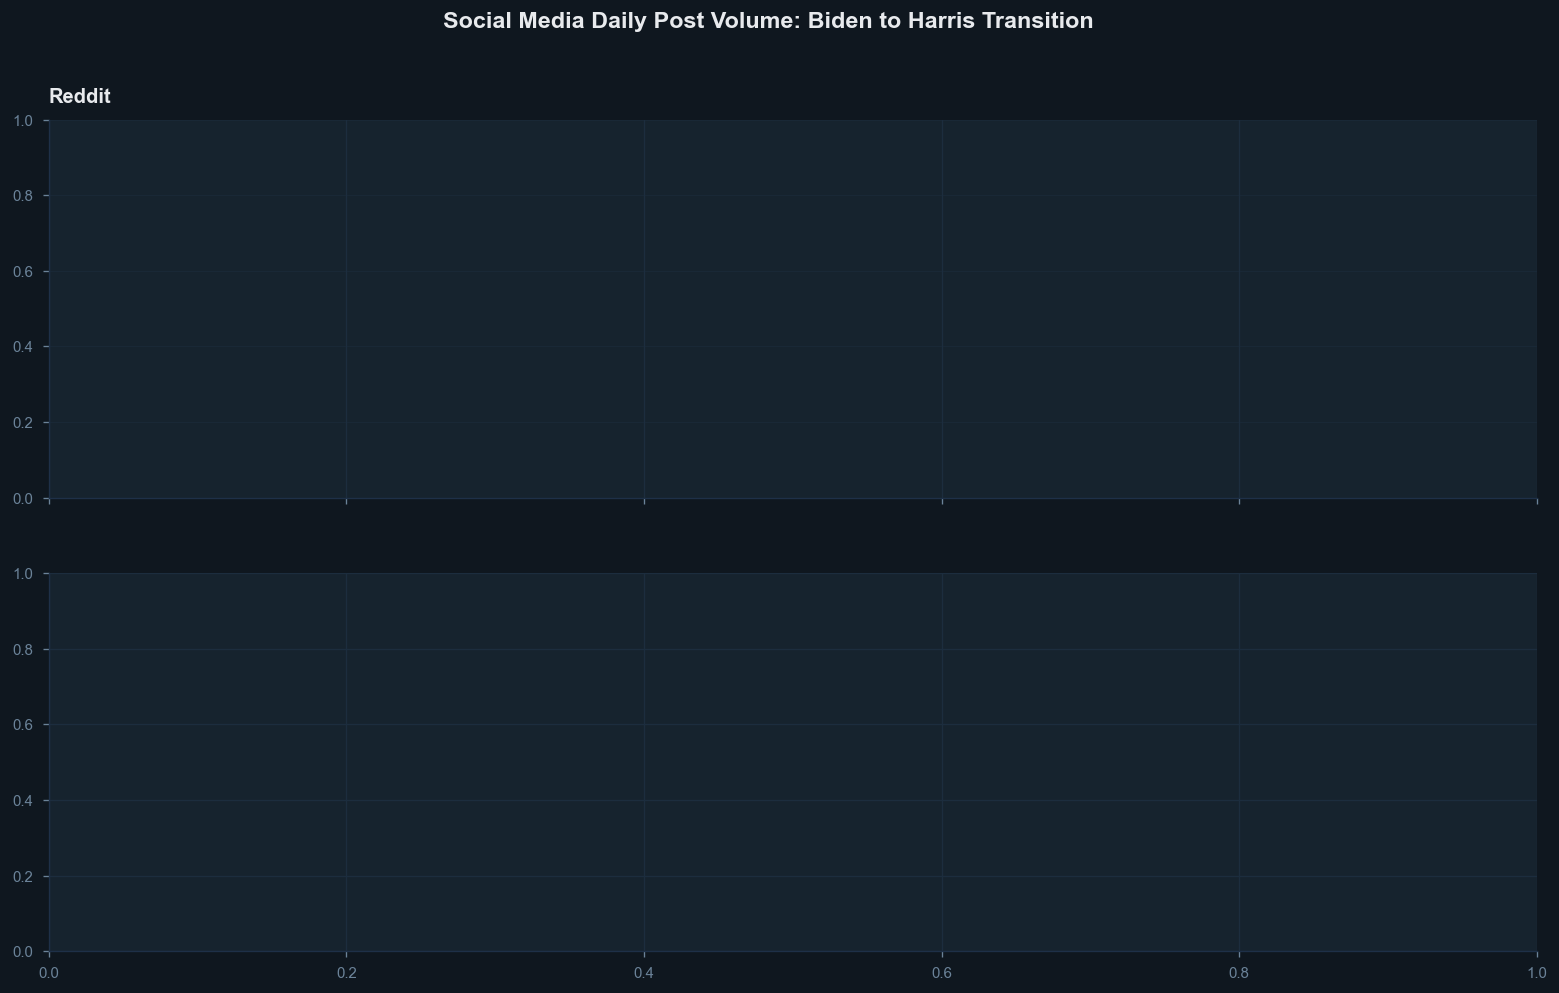

In [14]:
# ---------- Plot ----------
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, sharey=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(
    "Social Media Daily Post Volume: Biden to Harris Transition",
    fontweight="bold",
    fontsize=14
)

for ax, daily, title in [(axes[0], reddit_daily_df, "Reddit"), (axes[1], bsky_daily_df, "Bluesky")]:
    # base style
    if "style_ax_noevents" in globals():
        style_ax_noevents(ax, title)
    else:
        ax.set_title(title, fontweight="bold")

    cols = ["ElectionBuzz", "HarrisBuzz", "TrumpBuzz"]
    colors = [BUZZ_COLORS.get(c, TEXT_MUTED) for c in cols]

    ax.stackplot(
        daily.index,
        [daily[c].values for c in cols],
        labels=cols,
        colors=colors,
        alpha=0.82
    )

    # period Biden out -> Harris nomination
    if "BIDEN_OUT" in globals() and "HARRIS_NOM" in globals():
        ax.axvspan(
            pd.to_datetime(BIDEN_OUT),
            pd.to_datetime(HARRIS_NOM),
            alpha=0.10,
            color="white",
            zorder=0
        )

    # events
    if "add_events" in globals():
        add_events(ax, alpha=0.45)
    elif "EVENTS3" in globals():
        for date, lbl, color in EVENTS3:
            ax.axvline(
                pd.to_datetime(date),
                color=color,
                linestyle="--",
                linewidth=1.4,
                alpha=0.9,
                zorder=4
            )

    ax.set_ylabel("Posts per day")
    ax.legend(loc="upper left", fontsize=8)

# format x-axis only at the bottom
if "fmt_xaxis" in globals():
    fmt_xaxis(axes[1])
for _ax in axes:
    _ax.set_xlim(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-11-04'))

plt.subplots_adjust(left=0.06, right=0.97, top=0.93, bottom=0.10, hspace=0.20)

# optional: event legend at the bottom
if "event_legend" in globals():
    event_legend(fig)

plt.show()



## 4. Polymarket × Multi-Source Composite

/var/folders/4r/kx0lc74n42j94_8kv0y_lcm80000gn/T/ipykernel_18528/1964995734.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


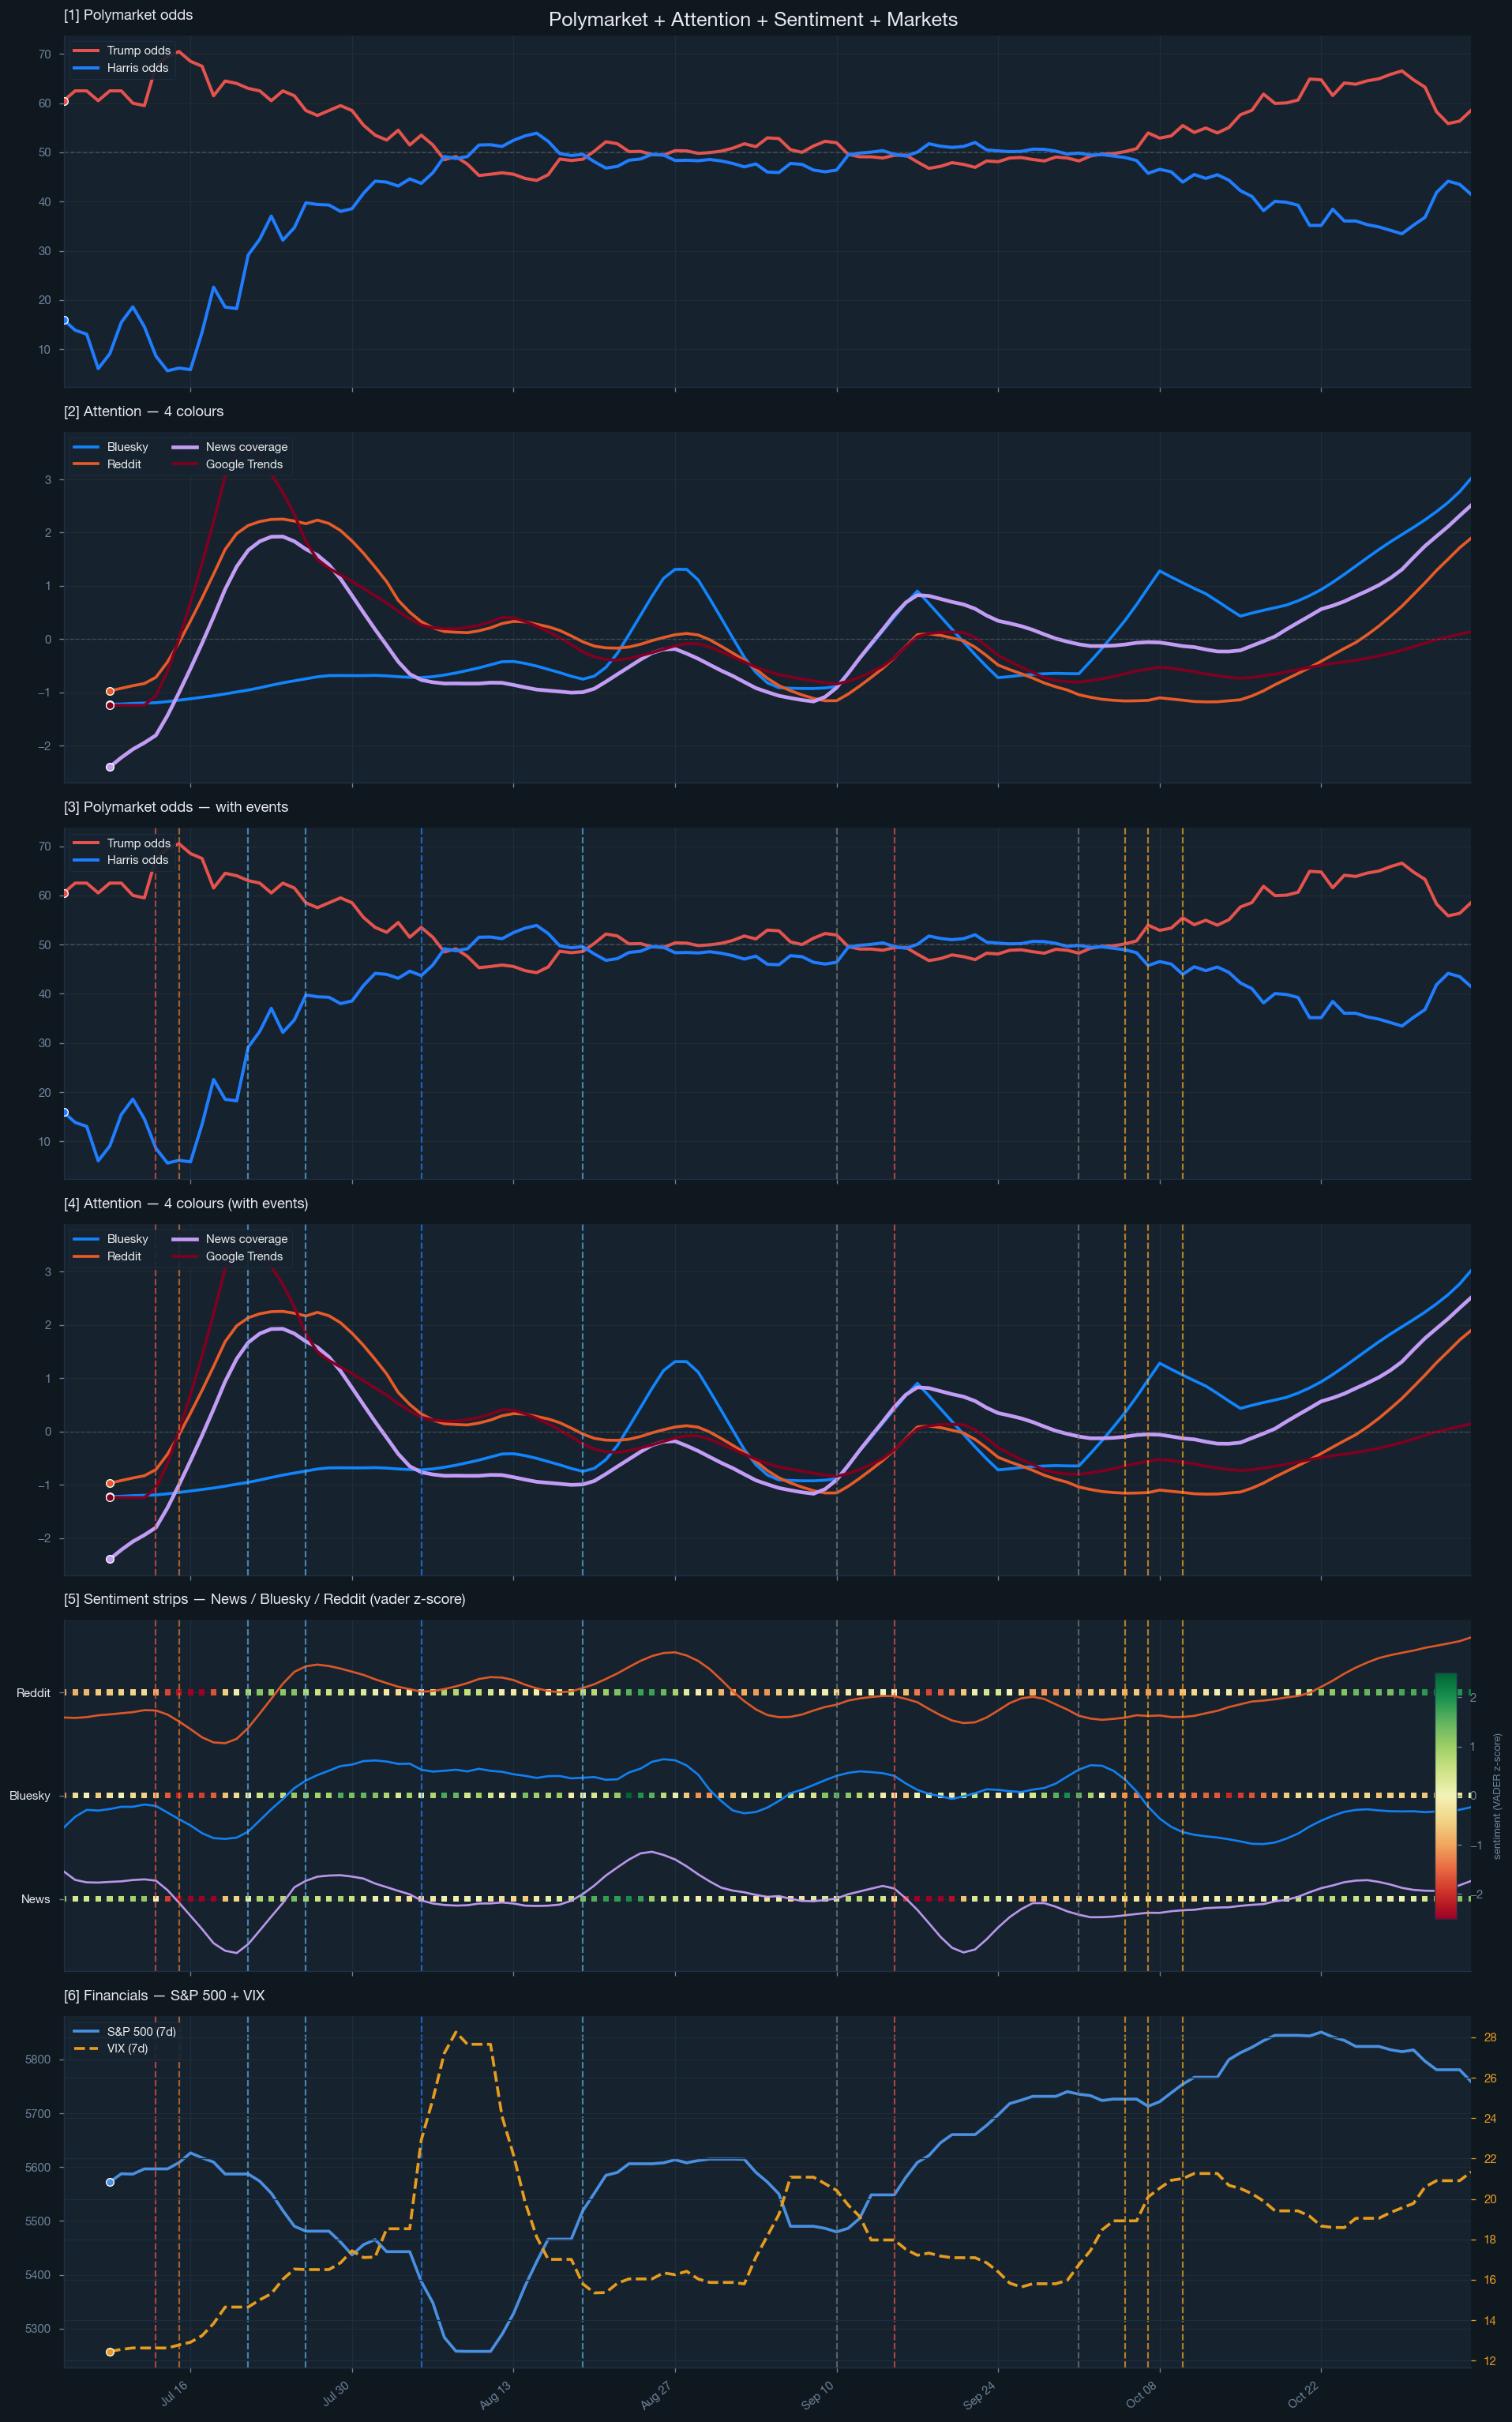

Sentiment loaded: News=yes, Bluesky=yes, Reddit=yes


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "df" not in globals():
    raise RuntimeError("`df` missing. Run the load/merge cell first.")
if "SILVER" not in globals():
    SILVER = Path("../../Data/2_Silver")

# ---- colour fallbacks ----
BG_DARK      = globals().get("BG_DARK",      "#111111")
BG_PANEL     = globals().get("BG_PANEL",     "#1b1b1b")
SPINE_COLOR  = globals().get("SPINE_COLOR",  "#3a3a3a")
TEXT_PRIMARY = globals().get("TEXT_PRIMARY", "#f2f2f2")
TEXT_MUTED   = globals().get("TEXT_MUTED",   "#b0b0b0")
C_TRUMP      = globals().get("C_TRUMP",      "#e74c3c")
C_HARRIS     = globals().get("C_HARRIS",     "#3498db")
C_SP500      = globals().get("C_SP500",      "#2ecc71")
C_VIX        = globals().get("C_VIX",        "#f39c12")
BLUESKY_BLUE = globals().get("BLUESKY_BLUE", "#4da3ff")
REDDIT_ORG   = globals().get("REDDIT_ORG",   "#ff6b35")
NEWS_RED     = "#C39DF5"
GT_BORDEAUX  = "#800020"

SENT_COLORS = {"News": NEWS_RED, "Bluesky": BLUESKY_BLUE, "Reddit": REDDIT_ORG}

def _safe_add_events(ax):
    if "add_events" in globals(): add_events(ax)

def _safe_fmt_xaxis(ax):
    if "fmt_xaxis" in globals(): fmt_xaxis(ax)

def _style(ax, title):
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(SPINE_COLOR)
    ax.grid(axis="y", color="#2d2d2d", linewidth=0.6, alpha=0.7)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=11, fontweight="bold", loc="left")
    ax.tick_params(colors=TEXT_MUTED)

def _zroll(series, window=7):
    s = pd.Series(series).rolling(window, min_periods=3).mean()
    mu = s.mean(skipna=True); sd = s.std(skipna=True)
    if pd.isna(sd) or sd == 0: return s * 0
    return (s - mu) / sd

def _align(values, date_index):
    if values is None: return pd.Series(np.nan, index=date_index)
    if isinstance(values, pd.DataFrame): values = values.iloc[:, 0]
    s = pd.Series(values)
    if isinstance(s.index, pd.DatetimeIndex):
        idx = pd.to_datetime(s.index, errors="coerce")
        if getattr(idx, "tz", None) is not None: idx = idx.tz_convert(None)
        idx = idx.normalize()
        s = pd.Series(s.to_numpy(), index=idx).groupby(level=0).mean().reindex(date_index)
    else:
        s = pd.Series(s.to_numpy())
        if len(s) == len(date_index): s.index = date_index
        else: s = pd.Series(np.nan, index=date_index)
    return s.astype(float)

def _nz(values, date_index):
    if values is None: return None
    y = _align(_zroll(values), date_index)
    return y if y.notna().any() else None

def _load_first(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return pd.read_parquet(p) if p.suffix.lower() == ".parquet" else pd.read_csv(p, low_memory=False, encoding_errors="ignore")
    return None

def _normalize_date(frame):
    f = frame.copy()
    for c in ["date", "timestamp", "created_utc"]:
        if c in f.columns:
            if c == "created_utc" and pd.api.types.is_numeric_dtype(f[c]):
                d = pd.to_datetime(f[c], unit="s", utc=True, errors="coerce")
            else:
                d = pd.to_datetime(f[c], utc=True, errors="coerce")
            f["date"] = d.dt.tz_convert(None).dt.normalize()
            return f
    f["date"] = pd.NaT
    return f

def _infer_sent(frame):
    for c in ["vader_compound", "compound", "sentiment", "sentiment_score", "polarity"]:
        if c in frame.columns:
            return pd.to_numeric(frame[c], errors="coerce")
    pos = [c for c in ["joy", "trust", "anticipation"] if c in frame.columns]
    neg = [c for c in ["anger", "fear", "sadness", "disgust"] if c in frame.columns]
    if pos and neg: return frame[pos].mean(axis=1) - frame[neg].mean(axis=1)
    return None

def _plot_series(ax, y, color, label, lw=2.2, ls="-"):
    if y is None or not y.notna().any(): return None
    ax.plot(y.index, y.values, color=color, lw=lw, ls=ls, label=label)
    first = y.first_valid_index()
    if first is not None:
        ax.scatter(first, y.loc[first], s=34, color=color, edgecolor="white", linewidth=0.8, zorder=5)
    valid = y.dropna().index
    return (valid.min(), valid.max())

def _prep_sent(values, date_index, roll=5, clip=2.5):
    s = _align(values, date_index).reindex(date_index).astype(float)
    s = s.interpolate(method="time", limit=10, limit_direction="both").ffill().bfill()
    x = s.rolling(roll, min_periods=1).mean()
    mu, sd = x.mean(skipna=True), x.std(skipna=True)
    if pd.isna(sd) or sd == 0: return pd.Series(0.0, index=date_index)
    return ((x - mu) / sd).clip(-clip, clip)

# ── Data prep ─────────────────────────────────────────────────────────────────
# Full daily series — prevents gaps from missing dates in df
date_index = pd.date_range("2024-07-05", "2024-11-04", freq="D")

# News sentiment
if "news_sent_level" in df.columns:
    _ns_raw = df.set_index(pd.to_datetime(df["date"]).dt.normalize())["news_sent_level"]
    news_sent_raw = _ns_raw
else:
    _nc = [c for c in ["vader_compound_mean_dem","vader_compound_mean_rep","vader_compound_mean_cen"] if c in df.columns]
    if _nc:
        _ns = df[_nc].mean(axis=1)
        _ns.index = pd.to_datetime(df["date"]).dt.normalize()
        news_sent_raw = _ns
    else:
        news_sent_raw = None

# Bluesky
bsky_df = _load_first([
    SILVER / "bluesky/sentiment_bluesky.csv",
    SILVER / "Bluesky/sentiment_bluesky.csv",
    SILVER / "Bluesky/bluesky_clean.csv",
])
if bsky_df is not None:
    bsky_df = _normalize_date(bsky_df).dropna(subset=["date"])
    bsky_daily = bsky_df.groupby("date").size().rename("bsky_posts")
    _bs = _infer_sent(bsky_df)
    bsky_sent_daily = bsky_df.assign(_s=_bs).groupby("date")["_s"].mean() if _bs is not None else None
else:
    bsky_daily = None; bsky_sent_daily = None

# Reddit
reddit_sent_df = _load_first([
    SILVER / "Reddit/sentiment_reddit.csv",
    SILVER / "Reddit/reddit_sentiment.parquet",
    SILVER / "Reddit/reddit_sentiment.csv",
    SILVER / "Reddit/reddit_posts_sentiment.csv",
])
reddit_posts_df = _load_first([
    SILVER / "Reddit/reddit_posts_clean.parquet",
    SILVER / "Reddit/reddit_posts_clean.csv",
])
if reddit_posts_df is not None:
    reddit_posts_df = _normalize_date(reddit_posts_df).dropna(subset=["date"])
    reddit_daily = reddit_posts_df.groupby("date").size().rename("reddit_posts")
else:
    reddit_daily = None
if reddit_sent_df is not None:
    reddit_sent_df = _normalize_date(reddit_sent_df).dropna(subset=["date"])
    _rs = _infer_sent(reddit_sent_df)
    reddit_sent_daily = reddit_sent_df.assign(_s=_rs).groupby("date")["_s"].mean() if _rs is not None else None
else:
    reddit_sent_daily = None

# Attention aggregates
_df_idx = df.copy(); _df_idx.index = pd.to_datetime(df["date"]).dt.normalize()
_df_idx = _df_idx[~_df_idx.index.duplicated()].reindex(date_index)

gt_cols = [c for c in ["gt_trump","gt_kamala","gt_biden","gt_elon","gt_election","gt_vote",
                        "gt_conspiracy","gt_walz","gt_vance","gt_campaign"] if c in df.columns]
gt_all_agg  = _df_idx[gt_cols].sum(axis=1).rolling(7, min_periods=3).mean() if gt_cols else None
media_agg   = _df_idx["total_coverage_7d"] if "total_coverage_7d" in _df_idx.columns else None
bsky_agg    = _align(bsky_daily,   date_index).rolling(7, min_periods=3).mean() if bsky_daily   is not None else None
reddit_agg  = _align(reddit_daily, date_index).rolling(7, min_periods=3).mean() if reddit_daily is not None else None

y_trump  = _align(_df_idx["trump_odds"],  date_index) if "trump_odds"  in _df_idx.columns else None
y_harris = _align(_df_idx["harris_odds"], date_index) if "harris_odds" in _df_idx.columns else None
y_bsky_att   = _nz(bsky_agg,   date_index)
y_reddit_att = _nz(reddit_agg, date_index)
y_media_att  = _nz(media_agg,  date_index)
y_gt_att     = _nz(gt_all_agg, date_index)
_sp = _df_idx["SP500"].rolling(7, min_periods=3).mean() if "SP500" in _df_idx.columns else None
_vx = _df_idx["VIX"].rolling(7,   min_periods=3).mean() if "VIX"   in _df_idx.columns else None
y_sp500 = _align(_sp, date_index) if _sp is not None else None
y_vix   = _align(_vx, date_index) if _vx is not None else None

# Sentiment strips — full date_index, gaps are interpolated
sent_strip = pd.DataFrame({
    "News":    _prep_sent(news_sent_raw,     date_index) if news_sent_raw    is not None else np.nan,
    "Bluesky": _prep_sent(bsky_sent_daily,   date_index) if bsky_sent_daily  is not None else np.nan,
    "Reddit":  _prep_sent(reddit_sent_daily, date_index) if reddit_sent_daily is not None else np.nan,
}, index=date_index)
sent_strip = sent_strip.loc[:, sent_strip.notna().any()]

# X-axis left boundary = first date of Google Trends
gt_xmin = None
if y_gt_att is not None and y_gt_att.notna().any():
    gt_xmin = y_gt_att.first_valid_index()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(16, 26), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle("Polymarket + Attention + Sentiment + Markets", color=TEXT_PRIMARY, fontsize=15, fontweight="bold")

all_windows = []

ax = axes[0]; _style(ax, "[1] Polymarket odds")
for y, c, lbl in [(y_trump, C_TRUMP, "Trump odds"), (y_harris, C_HARRIS, "Harris odds")]:
    w = _plot_series(ax, y, c, lbl, lw=2.4)
    if w: all_windows.append(w)
ax.axhline(50, color=TEXT_MUTED, lw=0.9, ls="--", alpha=0.45)
ax.legend(loc="upper left")

ax = axes[1]; _style(ax, "[2] Attention — 4 colours")
for y, c, lbl, lw in [(y_bsky_att, BLUESKY_BLUE, "Bluesky", 2.2), (y_reddit_att, REDDIT_ORG, "Reddit", 2.2),
                       (y_media_att, NEWS_RED, "News coverage", 2.8), (y_gt_att, GT_BORDEAUX, "Google Trends", 2.2)]:
    w = _plot_series(ax, y, c, lbl, lw=lw)
    if w: all_windows.append(w)
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls="--", alpha=0.4)
if ax.get_legend_handles_labels()[0]: ax.legend(loc="upper left", ncol=2)

ax = axes[2]; _style(ax, "[3] Polymarket odds — with events")
for y, c, lbl in [(y_trump, C_TRUMP, "Trump odds"), (y_harris, C_HARRIS, "Harris odds")]:
    w = _plot_series(ax, y, c, lbl, lw=2.4)
    if w: all_windows.append(w)
ax.axhline(50, color=TEXT_MUTED, lw=0.9, ls="--", alpha=0.45)
ax.legend(loc="upper left"); _safe_add_events(ax)

ax = axes[3]; _style(ax, "[4] Attention — 4 colours (with events)")
for y, c, lbl, lw in [(y_bsky_att, BLUESKY_BLUE, "Bluesky", 2.2), (y_reddit_att, REDDIT_ORG, "Reddit", 2.2),
                       (y_media_att, NEWS_RED, "News coverage", 2.8), (y_gt_att, GT_BORDEAUX, "Google Trends", 2.2)]:
    w = _plot_series(ax, y, c, lbl, lw=lw)
    if w: all_windows.append(w)
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls="--", alpha=0.4)
if ax.get_legend_handles_labels()[0]: ax.legend(loc="upper left", ncol=2)
_safe_add_events(ax)

ax = axes[4]; _style(ax, "[5] Sentiment strips — News / Bluesky / Reddit (vader z-score)")
if sent_strip.shape[1] > 0:
    last_scat = None
    for i, col in enumerate(sent_strip.columns):
        vals = sent_strip[col].values
        last_scat = ax.scatter(
            date_index, np.full(len(date_index), i),
            c=vals, cmap="RdYlGn", vmin=-2.5, vmax=2.5,
            marker="s", s=18, linewidths=0, alpha=0.95, zorder=2,
        )
        trend = pd.Series(vals, index=date_index).rolling(7, min_periods=1).mean()
        ax.plot(date_index, i + 0.28 * trend.values,
                color=SENT_COLORS.get(col, TEXT_PRIMARY), lw=1.6, alpha=0.95, zorder=3)
    ax.set_yticks(np.arange(sent_strip.shape[1]))
    ax.set_yticklabels(sent_strip.columns, color=TEXT_PRIMARY)
    ax.set_ylim(-0.7, sent_strip.shape[1] - 0.3)
    if last_scat is not None:
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes as _ia
        cax = _ia(ax, width="1.6%", height="70%", loc="center right", borderpad=1.2)
        cb = fig.colorbar(last_scat, cax=cax)
        cb.set_label("sentiment (VADER z-score)", color=TEXT_MUTED, fontsize=8)
        cb.ax.tick_params(colors=TEXT_MUTED)
        cb.outline.set_edgecolor(SPINE_COLOR)
else:
    ax.text(0.5, 0.5, "No sentiment data found", transform=ax.transAxes,
            ha="center", va="center", color=TEXT_MUTED)
_safe_add_events(ax)

ax = axes[5]; _style(ax, "[6] Financials — S&P 500 + VIX")
w = _plot_series(ax, y_sp500, C_SP500, "S&P 500 (7d)", lw=2.2)
if w: all_windows.append(w)
axr = ax.twinx(); axr.set_facecolor("none")
for sp in axr.spines.values(): sp.set_edgecolor(SPINE_COLOR)
axr.tick_params(colors=C_VIX)
if y_vix is not None and y_vix.notna().any():
    axr.plot(y_vix.index, y_vix.values, color=C_VIX, lw=2.2, ls="--", label="VIX (7d)")
    first = y_vix.first_valid_index()
    if first is not None:
        axr.scatter(first, y_vix.loc[first], s=34, color=C_VIX, edgecolor="white", linewidth=0.8, zorder=5)
    all_windows.append((y_vix.dropna().index.min(), y_vix.dropna().index.max()))
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = axr.get_legend_handles_labels()
if l1 or l2: ax.legend(l1+l2, lb1+lb2, loc="upper left")
_safe_add_events(ax)

if all_windows:
    for ax in axes:
        ax.set_xlim(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-11-04'))

for ax in axes: _safe_fmt_xaxis(ax)
plt.tight_layout()
plt.show()

print("Sentiment loaded:",
      f"News={'yes' if news_sent_raw is not None else 'no'},",
      f"Bluesky={'yes' if bsky_sent_daily is not None else 'no'},",
      f"Reddit={'yes' if reddit_sent_daily is not None else 'no'}")

## 6. Odds + Buzz with Flashpoints

/var/folders/4r/kx0lc74n42j94_8kv0y_lcm80000gn/T/ipykernel_18528/4138142416.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


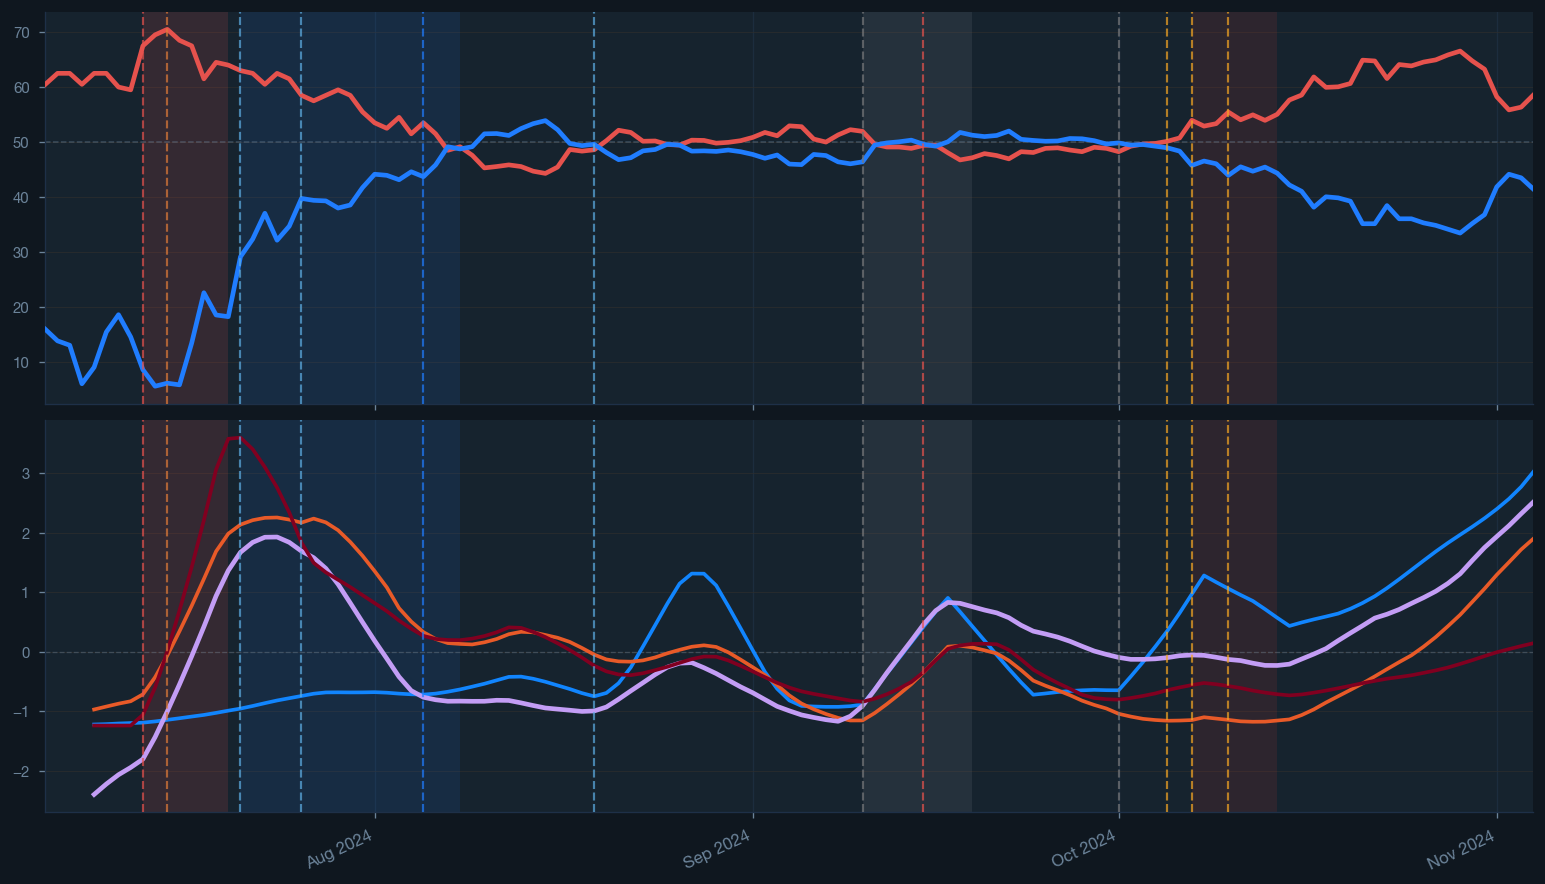

In [ ]:
# ── Version 3: odds (top) + buzz (bottom) with 4 flashpoints ────────────────────
# figsize=(16, 26/3) — 2 panels each as tall as 1 panel from the cell above (6 panels in 26")
FLASHPOINTS = [
    ('2024-07-13', '2024-07-20', REPUBLICAN, 0.15),
    ('2024-07-21', '2024-08-08', DEMOCRAT,   0.10),
    ('2024-09-10', '2024-09-19', '#6b7280',  0.18),
    ('2024-10-07', '2024-10-14', '#a83232',  0.16),
]

fig3, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(16, 26/3),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.04},
)
fig3.patch.set_facecolor(BG_DARK)

for ax in (ax_top, ax_bot):
    ax.set_facecolor(BG_PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
    ax.grid(axis='y', color='#2d2d2d', linewidth=0.6, alpha=0.7)
    ax.tick_params(colors=TEXT_MUTED)
    for s, e, color, alpha in FLASHPOINTS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   color=color, alpha=alpha, zorder=1, linewidth=0)

# ── Top: Polymarket odds ───────────────────────────────────────────────────────
if y_trump is not None and y_trump.notna().any():
    ax_top.plot(y_trump.index,  y_trump.values,  color=C_TRUMP,  lw=2.8, zorder=3)
if y_harris is not None and y_harris.notna().any():
    ax_top.plot(y_harris.index, y_harris.values, color=C_HARRIS, lw=2.8, zorder=3)
ax_top.axhline(50, color=TEXT_MUTED, lw=0.9, ls='--', alpha=0.45)
_safe_add_events(ax_top)

# ── Bottom: Buzz / Attention ───────────────────────────────────────────────────
for y, c, lw in [
    (y_bsky_att,   BLUESKY_BLUE, 2.2),
    (y_reddit_att, REDDIT_ORG,   2.2),
    (y_media_att,  NEWS_RED,     2.8),
    (y_gt_att,     GT_BORDEAUX,  2.2),
]:
    if y is not None and y.notna().any():
        ax_bot.plot(y.index, y.values, color=c, lw=lw, zorder=3)
ax_bot.axhline(0, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.4)
_safe_add_events(ax_bot)

# ── X-axis ──────────────────────────────────────────────────────────────────────
ax_top.set_xlim(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-11-04'))
ax_bot.set_xlim(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-11-04'))

ax_bot.xaxis.set_major_locator(mdates.MonthLocator())
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax_bot.get_xticklabels(), rotation=25, ha='right',
         color=TEXT_MUTED, fontsize=10)

plt.tight_layout()
plt.show()